In [1]:
# exp_008 — GoogLeNet/InceptionV1 · Tiny ImageNet
# Mesmo que exp_007 mas com AdamW ao invés de SGD
# Hipótese: AdamW oferece convergência mais rápida e adaptativa,
# especialmente com Mixup. Testa se o otimizador era gargalo.
# Isolamento: dropout 0.25 + aux_weight 0.2 mantêm variáveis controladas.

import datetime

EXPERIMENTO = {
    "id": "exp_008",
    "hipotese": (
        "AdamW (vs SGD) oferece convergência adaptativa. Mesmo dropout/aux_weight que exp_007 "
        "permite isolamento do efeito do otimizador."
    ),
    "mudancas": [
        "[exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)",
        "[exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)",
        "[exp_002] main_dropout: 0.4 → 0.55 → 0.25",
        "[exp_004] loss_weight auxiliar: 0.3 → 0.4 → 0.2",
        "[exp_004] ReduceLROnPlateau patience: 5 → 8",
        "[exp_004] LR warmup: 5 épocas (0.001 → 0.01)",
        "[exp_004] augmentation: nível exp_002",
        "[exp_005] stem_c2: stride=2, he_normal",
        "[exp_006] Mixup Augmentation: alpha=0.2",
        "[exp_006] label_smoothing: 0.0 (removido)",
        "[exp_007] dropout: 0.25 | aux_weight: 0.2",
        "[exp_008] ⚠️ OTIMIZADOR: SGD → AdamW [experimento isolado]",
    ],
    "resultado_top1": None,
    "resultado_top5": None,
    "epocas": None,
}

print(f"[{datetime.datetime.now():%Y-%m-%d %H:%M}] {EXPERIMENTO['id']}")
print(f"Hipótese: {EXPERIMENTO['hipotese']}")
print("\nMudanças acumuladas:")
for m in EXPERIMENTO["mudancas"]:
    print(f"  • {m}")



[2026-05-07 13:06] exp_008
Hipótese: AdamW (vs SGD) oferece convergência adaptativa. Mesmo dropout/aux_weight que exp_007 permite isolamento do efeito do otimizador.

Mudanças acumuladas:
  • [exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)
  • [exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)
  • [exp_002] main_dropout: 0.4 → 0.55 → 0.25
  • [exp_004] loss_weight auxiliar: 0.3 → 0.4 → 0.2
  • [exp_004] ReduceLROnPlateau patience: 5 → 8
  • [exp_004] LR warmup: 5 épocas (0.001 → 0.01)
  • [exp_004] augmentation: nível exp_002
  • [exp_005] stem_c2: stride=2, he_normal
  • [exp_006] Mixup Augmentation: alpha=0.2
  • [exp_006] label_smoothing: 0.0 (removido)
  • [exp_007] dropout: 0.25 | aux_weight: 0.2
  • [exp_008] ⚠️ OTIMIZADOR: SGD → AdamW [experimento isolado]


## Histórico de Experimentos

| ID | Mudanças-chave | Top-1 val (main) | Top-1 val (aux) | Top-5 val | Δ Top-1 |
|---|---|---|---|---|---|
| baseline | Modelo original | 39.88% | — | — | — |
| exp_001 | inception_5a/5b: canais reduzidos ~30% | 40.08% | 44.76% | 71.05% | +4.88pp (aux) |
| exp_002 | main_dropout: 0.4 → 0.55 | 39.29%* | 46.58% | 71.79% | +1.82pp (aux) |
| exp_003 | label_smoothing 0.1 (ambas) + ReduceLR patience=5 + aug+ | 0.50% ❌ | 2.50% ❌ | 2.50% ❌ | colapso (16 épocas) |
| exp_004 | label_smoothing 0.05 (só main) + peso aux 0.4 + warmup | 41.88% | 47.52% | 71.91% | +0.94pp (aux) |
| exp_005 | Stem: stride conv (stem_c2 stride=2, he_normal) + sem stem_pool | **45.27%** | 38.35% | 70.31% | +3.39pp (main)† |
| **exp_006** | **Mixup alpha=0.2 + sem label_smoothing + 120 épocas** | *(pendente)* | *(pendente)* | *(pendente)* | — |

> \*O Top-1 do exp_002 reportado pelo `evaluate()` usa a saída principal (39.29%).
> A saída auxiliar atingiu 46.58% — gap de ~7pp que exp_004/005 visam eliminar.
>
> †exp_005: o gap main/aux **inverteu** — a saída principal (45.27%) superou a auxiliar (38.35%)
> pela primeira vez. Sinal de que a nova Stem melhorou o fluxo de gradiente até a cabeça principal.
> O Δ é calculado em relação ao melhor da exp_004 (47.52% aux); comparando apenas as saídas
> principais: exp_004 main=41.88% → exp_005 main=45.27% = **+3.39pp**.

## Resumo — exp_006
| Métrica | Baseline | EXP01 | EXP02 | EXP03 ❌ | EXP04 | EXP05 | **EXP06** |
|---|---|---|---|---|---|---|---|
| Top-1 val (principal) | 39.88% | 40.08% | 39.29% | 0.50% | 41.88% | 45.27% | *(pendente)* |
| Top-1 val (auxiliar) | — | 44.76% | 46.58% | 2.50% | 47.52% | 38.35% | *(pendente)* |
| Top-5 val | — | 71.05% | 71.79% | 2.50% | 71.91% | 70.31% | *(pendente)* |
| Épocas | — | 66 | 94 | 16 | 100 (melhor: 88) | 100 (melhor: 87) | *(pendente)* |

**Mudanças acumuladas vs baseline:**
- `inception_5a/5b`: canais reduzidos ~30% (exp_001)
- `main_dropout`: 0.4 → 0.55 (exp_002)
- `loss_weight` auxiliar: 0.3 → 0.4 (exp_004)
- `ReduceLROnPlateau` patience: 5 → 8 (exp_004)
- `LR warmup`: 5 épocas de 0.001 → 0.01 (exp_004)
- `stem_c2`: stride=2, `he_normal` — `stem_pool` removido (exp_005)
- **`Mixup` alpha=0.2 — `label_smoothing` removido (exp_006)** ← mudança isolada
- **`EarlyStopping` patience: 20 → 25 (exp_006)**
- **Épocas máx: 100 → 120 (exp_006)**

**Por que remover label_smoothing com Mixup?**
> Mixup já cria soft labels ao interpolar $\tilde{y} = \lambda y_i + (1-\lambda) y_j$.
> Manter `label_smoothing=0.05` em cima disso aplica uma segunda suavização,
> o que pode impedir que a rede aprenda fronteiras de decisão claras entre classes.
> O efeito é cumulativo e tende a aumentar a loss sem benefício de regularização adicional.

**Por que 120 épocas com Mixup?**
> Com Mixup, a `train_loss` é artificialmente mais alta no início (problema mais difícil).
> O modelo tipicamente converge 20-30 épocas mais tarde do que sem Mixup.
> Nos experimentos anteriores, o melhor resultado ocorreu nas épocas 87-88 com limite de 100 —
> havia espaço para melhoria. 120 épocas + ES patience=25 dá margem suficiente sem
> custo computacional excessivo.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools, math, csv, os, shutil, zipfile, warnings, datetime
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-05-07 13:06:28.836814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778159189.056789      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778159189.127506      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778159189.638253      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159189.638286      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778159189.638289      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
EPOCHS         = 120
BATCH_SIZE     = 128
NUM_CLASSES    = 200
IMG_SIZE       = 64
INITIAL_LR     = 0.001     # AdamW usa LR menor que SGD
WARMUP_EPOCHS  = 5
WARMUP_LR      = 0.00005   # warmup mais conservador para AdamW
DROPOUT_MAIN   = 0.25
LABEL_SMOOTH   = 0.0
AUX_WEIGHT     = 0.2
MIXUP_ALPHA    = 0.2

tf.random.set_seed(42)
np.random.seed(42)
print(f"{EPOCHS} épocas | batch {BATCH_SIZE} | {IMG_SIZE}×{IMG_SIZE} | {NUM_CLASSES} classes")
print(f"dropout={DROPOUT_MAIN} | aux_weight={AUX_WEIGHT}")
print(f"[exp_008] Otimizador: AdamW | LR: {INITIAL_LR} (com warmup {WARMUP_EPOCHS} épocas)")
print(f"[exp_008] LR warmup: {WARMUP_EPOCHS} épocas ({WARMUP_LR} → {INITIAL_LR})")
print(f"[exp_008] Mixup alpha={MIXUP_ALPHA} | EarlyStopping patience=25")



120 épocas | batch 128 | 64×64 | 200 classes
dropout=0.25 | aux_weight=0.2
[exp_008] Otimizador: AdamW | LR: 0.001 (com warmup 5 épocas)
[exp_008] LR warmup: 5 épocas (5e-05 → 0.001)
[exp_008] Mixup alpha=0.2 | EarlyStopping patience=25


In [4]:
TINY_URL = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
DATA_DIR = Path('/kaggle/working/tiny-imagenet-200')
ZIP_PATH = Path('/kaggle/working/tiny-imagenet-200.zip')

if not ZIP_PATH.exists():
    print('Baixando Tiny ImageNet (~236 MB)...')
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    downloaded = 0
    with open(ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)
            downloaded += len(chunk)
            print(f'\r  {downloaded/1e6:.1f}/{total/1e6:.1f} MB', end='')
    print('\nDownload completo!')
else:
    print('ZIP já existe.')

if not DATA_DIR.exists():
    print('Extraindo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/kaggle/working')
    print('Extração concluída.')
else:
    print('Dataset já extraído.')

val_organized = DATA_DIR / 'val_organized'
if not val_organized.exists():
    print('Reorganizando val/...')
    val_organized.mkdir(parents=True)
    with open(DATA_DIR / 'val' / 'val_annotations.txt') as f:
        for line in f:
            fname, class_id = line.strip().split('\t')[:2]
            d = val_organized / class_id
            d.mkdir(exist_ok=True)
            shutil.copy(DATA_DIR / 'val' / 'images' / fname, d / fname)
    print(f'Val reorganizado: {len(list(val_organized.iterdir()))} classes')
else:
    print('val_organized já existe.')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = val_organized
print(f'Treino: {TRAIN_DIR} | Val: {VAL_DIR}')

Baixando Tiny ImageNet (~236 MB)...
  248.1/248.1 MB
Download completo!
Extraindo...
Extração concluída.
Reorganizando val/...
Val reorganizado: 200 classes
Treino: /kaggle/working/tiny-imagenet-200/train | Val: /kaggle/working/tiny-imagenet-200/val_organized


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)
CLASS_NAMES = train_ds.class_names
print(f'Classes: {len(CLASS_NAMES)}')

def normalize(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

# Augmentation base — nível exp_002/004 (sem RandomBrightness, rotação=0.1)
# Mixup é aplicado DEPOIS da augmentation base no pipeline
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='augmentation')

# ── Mixup ────────────────────────────────────────────────────────────────────
# Implementação vetorizada: opera sobre o batch inteiro sem loops Python.
# lambda ~ Beta(alpha, alpha); o batch é shuffled internamente para criar pares.
# Resultado: imagens e labels são misturas convexas de dois exemplos do batch.
@tf.function
def mixup(images, labels, alpha=MIXUP_ALPHA):
    batch_size = tf.shape(images)[0]

    # Amostra lambda da distribuição Beta(alpha, alpha)
    # tf.random.stateless não requer tensorflow_probability
    lam = tf.cast(
        tf.random.stateless_uniform([], seed=(42, 0), minval=0, maxval=1),
        tf.float32
    )
    # Aplica a simetria do Mixup: usa max(lam, 1-lam) para manter a imagem
    # dominante sempre acima de 0.5 — evita imagens 50/50 que confundem muito
    # Nota: para Beta(0.2,0.2) isso não é obrigatório mas melhora a legibilidade
    # dos exemplos de treino. Remova o max() para um Mixup mais agressivo.
    # lam = tf.math.maximum(lam, 1.0 - lam)

    # Shuffle do batch para criar pares aleatórios
    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)

    # Interpolação
    mixed_images = lam * images + (1.0 - lam) * images_shuffled
    mixed_labels = lam * labels + (1.0 - lam) * labels_shuffled
    return mixed_images, mixed_labels

def apply_augment_and_mixup(img, lbl):
    img = augment(img, training=True)
    img, lbl = mixup(img, lbl)
    return img, lbl

train_ds = (
    train_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .map(apply_augment_and_mixup, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
# Val: SEM Mixup — avaliação sempre com imagens reais
val_ds = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
print('Pipelines prontos (treino com Mixup, val sem Mixup).')

Found 100000 files belonging to 200 classes.


I0000 00:00:1778159240.047917      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778159240.053892      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 10000 files belonging to 200 classes.
Classes: 200
Pipelines prontos (treino com Mixup, val sem Mixup).


In [6]:
def inception_module(x, f1, f3r, f3, f5r, f5, fp, name):
    """Módulo Inception: 4 ramos paralelos (Szegedy et al., 2014)."""
    ki = 'glorot_uniform'
    bi = tf.keras.initializers.Constant(0.2)
    kw = dict(padding='same', activation='relu', kernel_initializer=ki, bias_initializer=bi)

    b1 = tf.keras.layers.Conv2D(f1,  (1,1), **kw, name=f'{name}_1x1')(x)

    b2 = tf.keras.layers.Conv2D(f3r, (1,1), **kw, name=f'{name}_3x3_reduce')(x)
    b2 = tf.keras.layers.Conv2D(f3,  (3,3), **kw, name=f'{name}_3x3')(b2)

    b3 = tf.keras.layers.Conv2D(f5r, (1,1), **kw, name=f'{name}_5x5_reduce')(x)
    b3 = tf.keras.layers.Conv2D(f5,  (5,5), **kw, name=f'{name}_5x5')(b3)

    b4 = tf.keras.layers.MaxPooling2D((3,3), strides=(1,1), padding='same', name=f'{name}_pool')(x)
    b4 = tf.keras.layers.Conv2D(fp,  (1,1), **kw, name=f'{name}_pool_proj')(b4)

    return tf.keras.layers.Concatenate(axis=-1, name=name)([b1, b2, b3, b4])

In [7]:
def build_googlenet(num_classes=200, img_size=64, dropout=0.55):
    """
    GoogLeNet adaptado para 64×64. Acumula mudanças de exp_001 a exp_005.

    Stem (exp_005):
      Conv3x3(64, stride=1, glorot) → 64×64
      Conv3x3(64, stride=2, he_normal) → 32×32   ← downsampling aprendível
      Conv3x3(192, stride=1, glorot) → 32×32
      [sem MaxPool]

    Bloco 5 (exp_001):
      inception_5a: 640ch  (reduzido de 832ch)
      inception_5b: 768ch  (reduzido de 1024ch)

    Cabeça principal (exp_002):
      Dropout 0.55
    """
    bi    = tf.keras.initializers.Constant(0.2)
    kw_g  = dict(padding='same', activation='relu',
                 kernel_initializer='glorot_uniform', bias_initializer=bi)
    kw_he = dict(padding='same', activation='relu',
                 kernel_initializer='he_normal', bias_initializer=bi)

    inp = tf.keras.layers.Input(shape=(img_size, img_size, 3), name='input')

    # ── Stem exp_005 ─────────────────────────────────────────────────────────
    x = tf.keras.layers.Conv2D(64,  (3,3), **kw_g,             name='stem_c1')(inp)  # 64×64
    x = tf.keras.layers.Conv2D(64,  (3,3), strides=2, **kw_he, name='stem_c2')(x)    # 32×32
    x = tf.keras.layers.Conv2D(192, (3,3), **kw_g,             name='stem_c3')(x)    # 32×32

    # ── Bloco 3 ──────────────────────────────────────────────────────────────
    x = inception_module(x,  64,  96, 128, 16,  32,  32, 'inception_3a')
    x = inception_module(x, 128, 128, 192, 32,  96,  64, 'inception_3b')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_3')(x)

    # ── Bloco 4 ──────────────────────────────────────────────────────────────
    x = inception_module(x, 192,  96, 208, 16,  48,  64, 'inception_4a')

    # ── Classificador Auxiliar ───────────────────────────────────────────────
    aux = tf.keras.layers.AveragePooling2D((5,5), strides=3, padding='same', name='aux_pool')(x)
    aux = tf.keras.layers.Conv2D(128, (1,1), **kw_g, name='aux_conv')(aux)
    aux = tf.keras.layers.Flatten(name='aux_flat')(aux)
    aux = tf.keras.layers.Dense(1024, activation='relu', name='aux_dense')(aux)
    aux = tf.keras.layers.Dropout(0.3, name='aux_drop')(aux)
    aux_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='auxiliary_output')(aux)

    x = inception_module(x, 160, 112, 224, 24,  64,  64, 'inception_4b')
    x = inception_module(x, 128, 128, 256, 24,  64,  64, 'inception_4c')
    x = inception_module(x, 112, 144, 288, 32,  64,  64, 'inception_4d')
    x = inception_module(x, 256, 160, 320, 32, 128, 128, 'inception_4e')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_4')(x)

    # ── Bloco 5 — canais reduzidos (exp_001) ─────────────────────────────────
    x = inception_module(x, 192, 128, 256, 32,  96,  96, 'inception_5a')  # 640ch
    x = inception_module(x, 256, 160, 320, 32,  96,  96, 'inception_5b')  # 768ch

    # ── Cabeça principal — dropout 0.55 (exp_002) ────────────────────────────
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.Dropout(dropout, name='main_dropout')(x)
    main_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='main_output')(x)

    return tf.keras.Model(inputs=inp, outputs=[main_out, aux_out], name='GoogLeNet_exp008')


model = build_googlenet(NUM_CLASSES, IMG_SIZE, DROPOUT_MAIN)
model.summary()

print("\n── Verificação Stem exp_005/006 ──")
for name in ['stem_c1', 'stem_c2', 'stem_c3']:
    layer = model.get_layer(name)
    print(f"  {name}: output={layer.output.shape} | "
          f"kernel_initializer={layer.kernel_initializer.__class__.__name__} | "
          f"strides={layer.strides}")

Model: "GoogLeNet_exp008"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c1 (Conv2D)    │ (None, 64, 64,    │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c2 (Conv2D)    │ (None, 32, 32,    │     36,928 │ stem_c1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c3 (Conv2D)    │ (None, 32, 32,    │    110,784 │ stem_c2[0][0]     │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 32, 32,    │     18,528 │ stem_c3[0][0]     │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 32, 32,    │      3,088 │ stem_c3[0][0]     │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool   │ (None, 32, 32,    │          0 │ stem_c3[0][0]     │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_1x1    │ (None, 32, 32,    │     12,352 │ stem_c3[0][0]     │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3    │ (None, 32, 32,    │    110,720 │ inception_3a_3x3… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5    │ (None, 32, 32,    │     12,832 │ inception_3a_5x5… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool_… │ (None, 32, 32,    │      6,176 │ inception_3a_poo… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ inception_3a_1x1… │
│ (Concatenate)       │ 256)              │            │ inception_3a_3x3… │
│                     │                   │            │ inception_3a_5x5… │
│                     │                   │            │ inception_3a_poo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_3x3_r… │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_5x5_r… │ (None, 32, 32,    │      8,224 │ inception_3a[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_pool   │ (None, 32, 32,    │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_1x1    │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,287,152 (39.24 MB)

 Trainable params: 10,287,152 (39.24 MB)

 Non-trainable params: 0 (0.00 B)


── Verificação Stem exp_005/006 ──
  stem_c1: output=(None, 64, 64, 64) | kernel_initializer=GlorotUniform | strides=(1, 1)
  stem_c2: output=(None, 32, 32, 64) | kernel_initializer=HeNormal | strides=(2, 2)
  stem_c3: output=(None, 32, 32, 192) | kernel_initializer=GlorotUniform | strides=(1, 1)


In [8]:
# exp_008: AdamW (vs SGD) — mesmo dropout/aux_weight que exp_007
# Testa isoladamente o efeito do otimizador
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=WARMUP_LR,
        weight_decay=0.0001,  # L2 regularization
        beta_1=0.9,           # default
        beta_2=0.999,         # default
        epsilon=1e-7
    ),
    loss={
        'main_output':      tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
        'auxiliary_output': tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    },
    loss_weights={'main_output': 1.0, 'auxiliary_output': AUX_WEIGHT},
    metrics={'main_output': ['accuracy'], 'auxiliary_output': ['accuracy']},
)
print('Compilado com sucesso.')
print(f'  Otimizador: AdamW')
print(f'  LR inicial (warmup): {WARMUP_LR} | LR alvo: {INITIAL_LR}')
print(f'  weight_decay: 0.0001 (L2 regularization)')
print(f'  loss_weights: main=1.0 | auxiliary={AUX_WEIGHT}')



Compilado com sucesso.
  Otimizador: AdamW
  LR inicial (warmup): 5e-05 | LR alvo: 0.001
  weight_decay: 0.0001 (L2 regularization)
  loss_weights: main=1.0 | auxiliary=0.2


In [9]:
class LRWarmupCallback(tf.keras.callbacks.Callback):
    """Sobe o LR linearmente de warmup_lr até target_lr ao longo de warmup_epochs."""
    def __init__(self, warmup_epochs, warmup_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.warmup_lr     = warmup_lr
        self.target_lr     = target_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.warmup_lr + (self.target_lr - self.warmup_lr) * (epoch / self.warmup_epochs)
            self.model.optimizer.learning_rate.assign(lr)
            print(f'  [warmup] época {epoch+1}/{self.warmup_epochs} — LR = {lr:.5f}')
        elif epoch == self.warmup_epochs:
            self.model.optimizer.learning_rate.assign(self.target_lr)
            print(f'  [warmup] concluído — LR fixado em {self.target_lr}')

callbacks = [
    LRWarmupCallback(
        warmup_epochs=WARMUP_EPOCHS,
        warmup_lr=WARMUP_LR,
        target_lr=INITIAL_LR,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_main_output_accuracy', factor=0.5,
        patience=8, min_lr=1e-5, verbose=1, mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_main_output_accuracy', patience=25,   # exp_006: 20 → 25
        restore_best_weights=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'googlenet_exp008_best.keras', monitor='val_main_output_accuracy',
        save_best_only=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.CSVLogger('training_log_exp008.csv'),
]

In [10]:
def dual_labels(img, lbl):
    return img, (lbl, lbl)

train_ds_dual = train_ds.map(dual_labels)
val_ds_dual   = val_ds.map(dual_labels)

print(f'Iniciando exp_008 — {EPOCHS} épocas máx. | Mixup alpha={MIXUP_ALPHA}')
print(f'[AdamW | Dropout: {DROPOUT_MAIN} | Aux Weight: {AUX_WEIGHT}]')
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)



Iniciando exp_008 — 120 épocas máx. | Mixup alpha=0.2
[AdamW | Dropout: 0.25 | Aux Weight: 0.2]
  [warmup] época 1/5 — LR = 0.00005
Epoch 1/120


I0000 00:00:1778159259.115020      79 service.cc:152] XLA service 0x7bbd5c018260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778159259.115072      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778159259.115077      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778159262.648541      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778159303.006528      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - auxiliary_output_accuracy: 0.0063 - auxiliary_output_loss: 5.3093 - loss: 6.3877 - main_output_accuracy: 0.0055 - main_output_loss: 5.3258
Epoch 1: val_main_output_accuracy improved from -inf to 0.01510, saving model to googlenet_exp008_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 441s 488ms/step - auxiliary_output_accuracy: 0.0064 - auxiliary_output_loss: 5.3092 - loss: 6.3876 - main_output_accuracy: 0.0055 - main_output_loss: 5.3258 - val_auxiliary_output_accuracy: 0.0240 - val_auxiliary_output_loss: 5.0570 - val_loss: 6.1401 - val_main_output_accuracy: 0.0151 - val_main_output_loss: 5.1297 - learning_rate: 5.0000e-05
  [warmup] época 2/5 — LR = 0.00024
Epoch 2/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - auxiliary_output_accuracy: 0.0224 - auxiliary_output_loss: 5.1610 - loss: 6.2460 - main_output_accuracy: 0.0136 - main_output_loss: 5.2138
Epoch 2: val_main_output_accuracy improved from 0.01510 to 0.02940, saving model to googlenet_exp008

In [11]:
best_model = tf.keras.models.load_model('googlenet_exp008_best.keras')
results    = best_model.evaluate(val_ds_dual, verbose=0)
print('\nresults[] completo (para debug de índices):')
for i, v in enumerate(results):
    print(f'  results[{i}] = {v:.4f}')



results[] completo (para debug de índices):
  results[0] = 3.2998
  results[1] = 2.6944
  results[2] = 3.1028
  results[3] = 0.3225
  results[4] = 0.4027


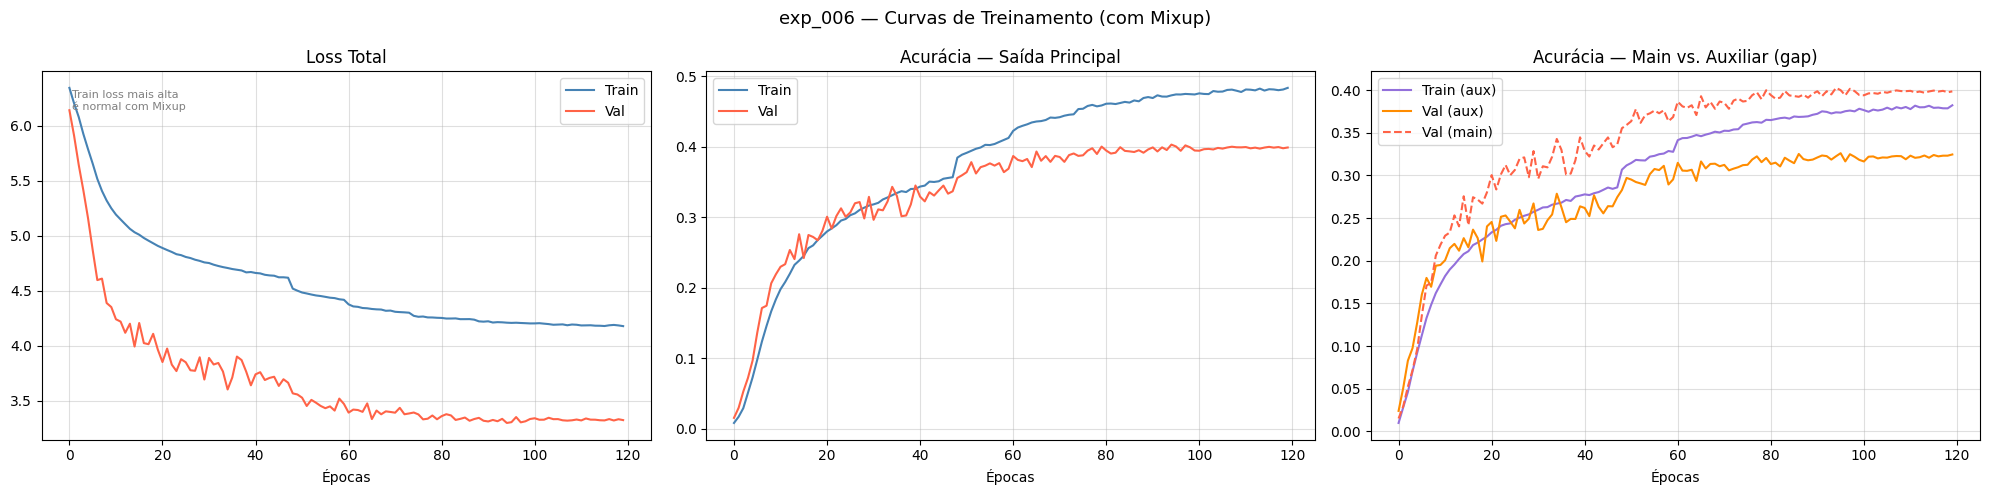

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss Total')
axes[0].set_xlabel('Épocas'); axes[0].legend(); axes[0].grid(alpha=0.4)
axes[0].annotate('Train loss mais alta\né normal com Mixup',
                 xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=8, color='gray', va='top')

axes[1].plot(history.history['main_output_accuracy'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_main_output_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Acurácia — Saída Principal')
axes[1].set_xlabel('Épocas'); axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(history.history['auxiliary_output_accuracy'],     label='Train (aux)', color='mediumpurple')
axes[2].plot(history.history['val_auxiliary_output_accuracy'], label='Val (aux)',   color='darkorange')
axes[2].plot(history.history['val_main_output_accuracy'],      label='Val (main)',  color='tomato', linestyle='--')
axes[2].set_title('Acurácia — Main vs. Auxiliar (gap)')
axes[2].set_xlabel('Épocas'); axes[2].legend(); axes[2].grid(alpha=0.4)

plt.suptitle('exp_006 — Curvas de Treinamento (com Mixup)', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves_exp008.png', dpi=150)
plt.show()

In [13]:
id_to_name = {}
words_file = DATA_DIR / 'words.txt'
if words_file.exists():
    with open(words_file) as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                id_to_name[parts[0]] = parts[1].split(',')[0]

idx_to_name = {i: id_to_name.get(cid, cid) for i, cid in enumerate(CLASS_NAMES)}
print('Mapeamento carregado.')

Mapeamento carregado.


In [14]:
# Coleta predições usando output[0] (main_output) diretamente — mais confiável
all_true, all_pred, all_probs = [], [], []
for imgs, (lbls, _) in val_ds_dual:
    lbl_idx = tf.argmax(lbls, axis=1).numpy()
    probs   = best_model(imgs, training=False)[0].numpy()  # [0] = main_output
    all_true.extend(lbl_idx)
    all_pred.extend(np.argmax(probs, axis=1))
    all_probs.append(probs)

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_probs = np.concatenate(all_probs, axis=0)

# Top-5
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)
top5_metric.update_state(all_true, all_probs)
top5_acc = top5_metric.result().numpy()

# Auxiliar — output[1]
all_probs_aux = []
for imgs, (_, _) in val_ds_dual:
    probs_aux = best_model(imgs, training=False)[1].numpy()  # [1] = auxiliary_output
    all_probs_aux.append(probs_aux)
all_probs_aux = np.concatenate(all_probs_aux, axis=0)
aux_acc = (np.argmax(all_probs_aux, axis=1) == all_true).mean()

per_class_acc = {
    c: (all_pred[all_true == c] == c).mean()
    for c in range(NUM_CLASSES) if (all_true == c).sum() > 0
}
sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
main_acc   = (all_true == all_pred).mean()

print(f"{'='*55}")
print(f"  Top-1 — Saída Principal  : {main_acc*100:.2f}%")
print(f"  Top-1 — Saída Auxiliar   : {aux_acc*100:.2f}%")
print(f"  Gap main/aux             : {abs(main_acc - aux_acc)*100:.2f}pp")
print(f"  Top-5 — Saída Principal  : {top5_acc*100:.2f}%")
print(f"  Média per-class (main)   : {np.mean(list(per_class_acc.values()))*100:.2f}%")
print(f"  Melhor classe            : {idx_to_name.get(sorted_acc[0][0])} ({sorted_acc[0][1]*100:.1f}%)")
print(f"  Pior classe              : {idx_to_name.get(sorted_acc[-1][0])} ({sorted_acc[-1][1]*100:.1f}%)")
print(f"{'='*55}")

  Top-1 — Saída Principal  : 40.27%
  Top-1 — Saída Auxiliar   : 32.25%
  Gap main/aux             : 8.02pp
  Top-5 — Saída Principal  : 66.12%
  Média per-class (main)   : 40.27%
  Melhor classe            : monarch (92.0%)
  Pior classe              : plunger (0.0%)


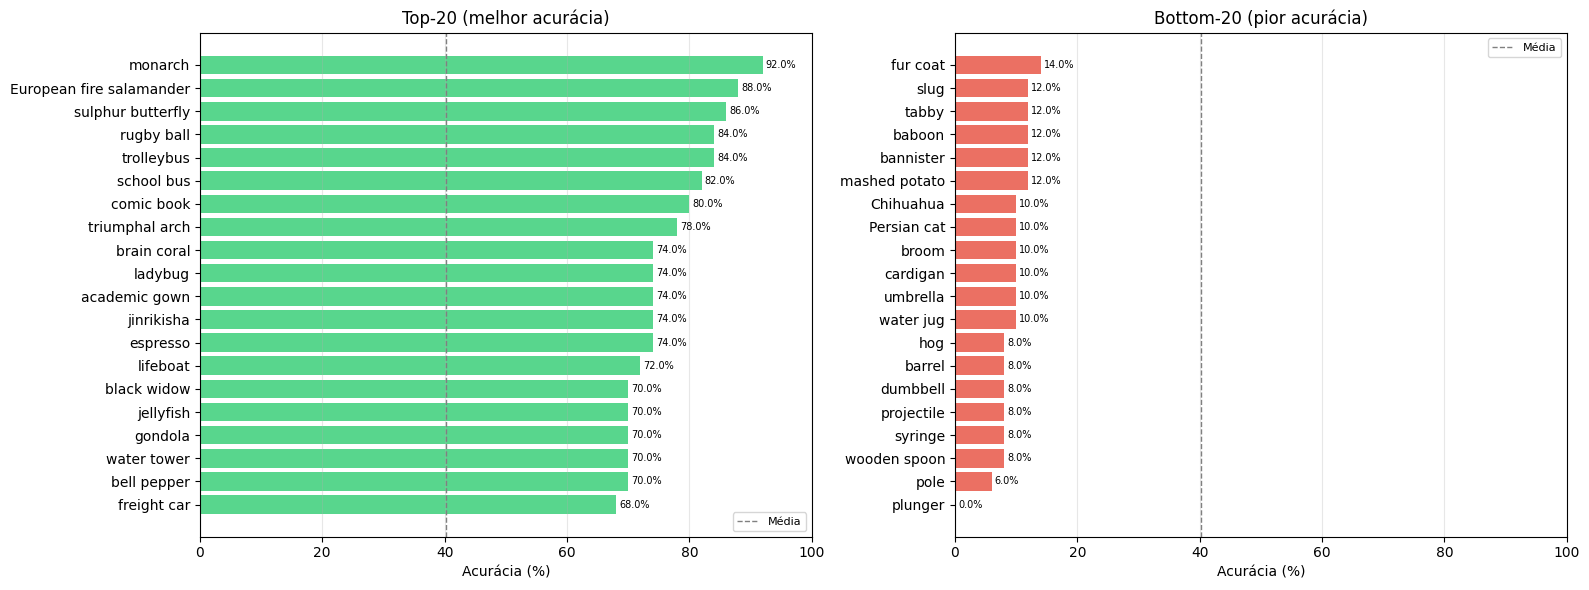

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in [
    (axes[0], sorted_acc[:20],  'Top-20 (melhor acurácia)', '#2ecc71'),
    (axes[1], sorted_acc[-20:], 'Bottom-20 (pior acurácia)', '#e74c3c'),
]:
    lbls = [idx_to_name.get(c, str(c)) for c, _ in data]
    vals = [v * 100 for _, v in data]
    bars = ax.barh(lbls[::-1], vals[::-1], color=color, alpha=0.8)
    ax.axvline(np.mean(list(per_class_acc.values())) * 100,
               color='gray', linestyle='--', lw=1, label='Média')
    ax.set_xlabel('Acurácia (%)'); ax.set_title(title)
    ax.set_xlim(0, 100); ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_exp008.png', dpi=150, bbox_inches='tight')
plt.show()

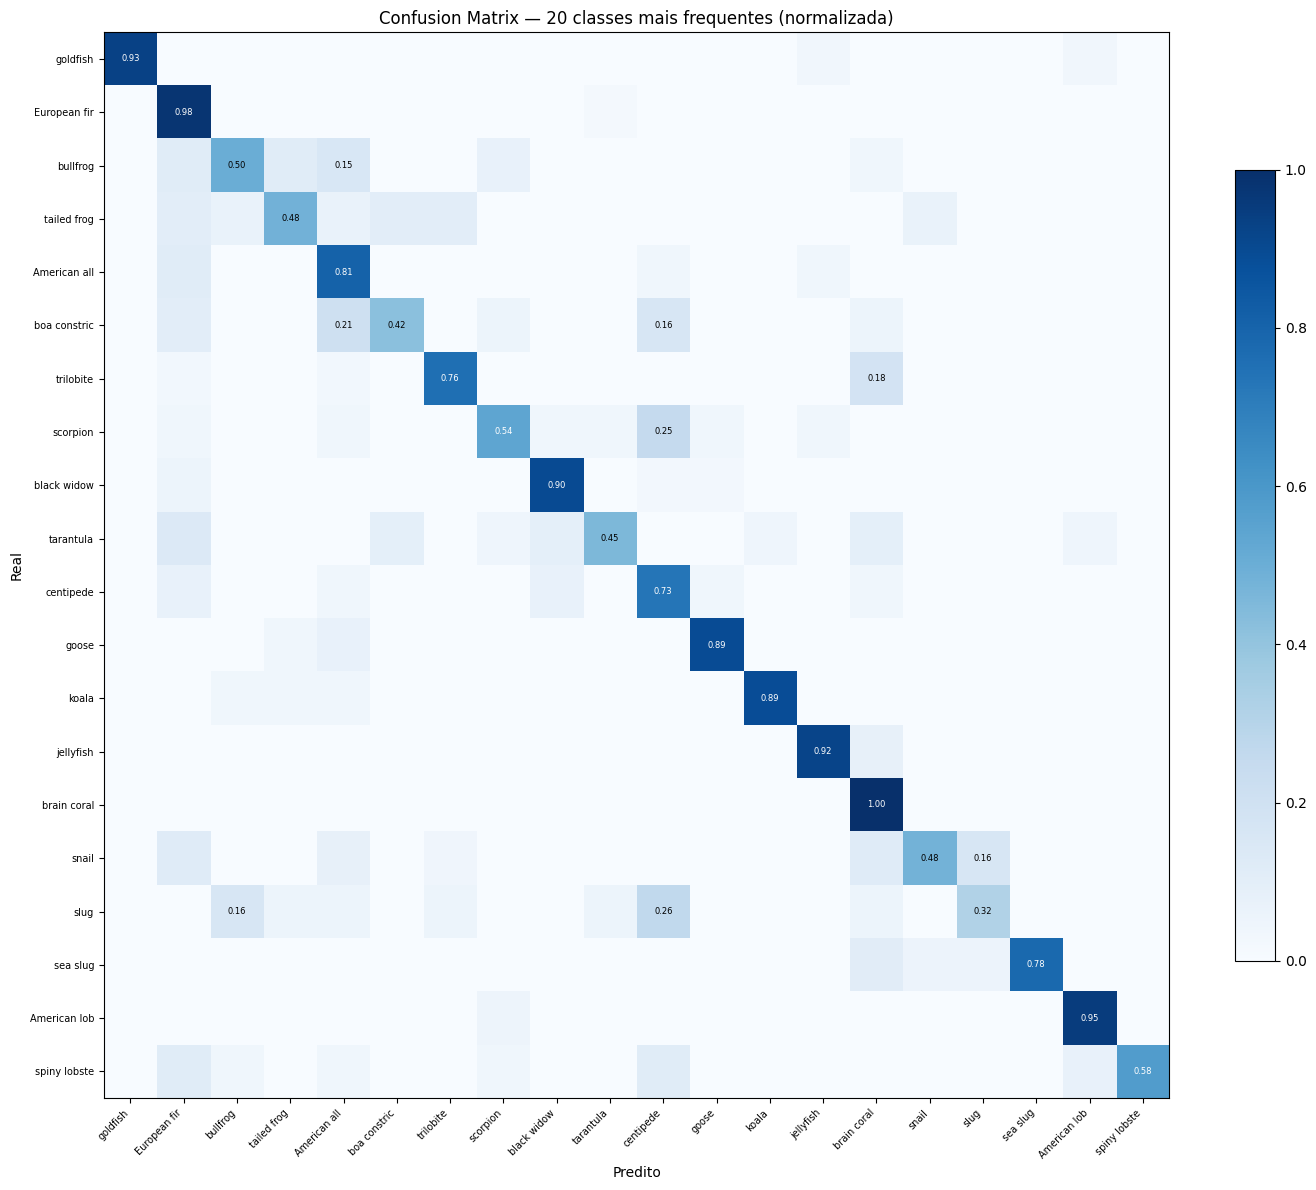

In [16]:
top20_idx = [c for c, _ in sorted(
    ((c, (all_true == c).sum()) for c in range(NUM_CLASSES)), key=lambda x: -x[1]
)[:20]]

mask = np.isin(all_true, top20_idx)
cm   = confusion_matrix(all_true[mask], all_pred[mask], labels=top20_idx)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
tick_lbl = [idx_to_name.get(c, str(c))[:12] for c in top20_idx]
ax.set_xticks(range(20)); ax.set_xticklabels(tick_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(20)); ax.set_yticklabels(tick_lbl, fontsize=7)
ax.set_title('Confusion Matrix — 20 classes mais frequentes (normalizada)')
ax.set_ylabel('Real'); ax.set_xlabel('Predito')
for i, j in itertools.product(range(20), range(20)):
    if cm_n[i, j] > 0.15:
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i,j] > 0.5 else 'black', fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix_exp008.png', dpi=150, bbox_inches='tight')
plt.show()

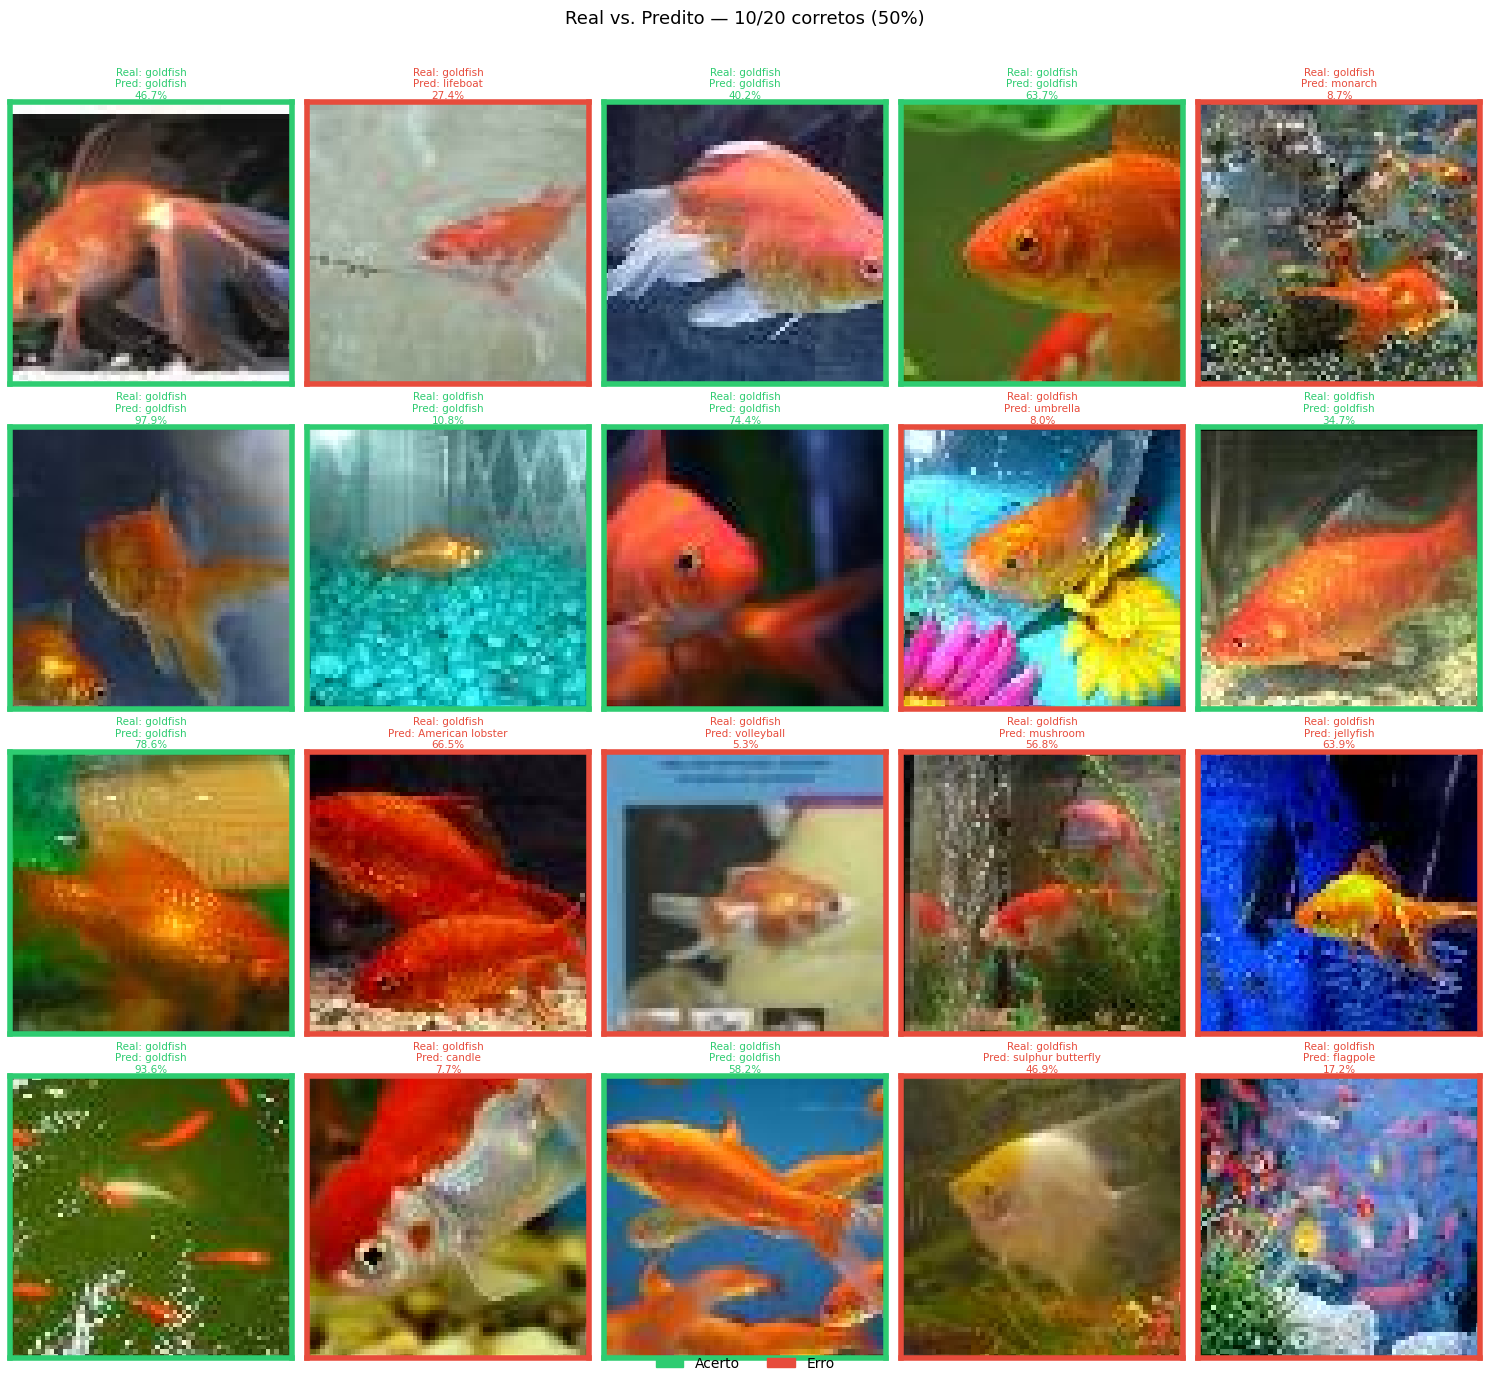

In [17]:
N, COLS = 20, 5
ROWS = math.ceil(N / COLS)

sample_imgs, (sample_lbls, _) = next(iter(val_ds_dual))
sample_imgs = sample_imgs[:N]
true_idx    = tf.argmax(sample_lbls[:N], axis=1).numpy()
probs_main  = best_model(sample_imgs, training=False)[0].numpy()
pred_idx    = np.argmax(probs_main, axis=1)
confs       = np.max(probs_main, axis=1)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*3, ROWS*3.4))
for i, ax in enumerate(axes.flat[:N]):
    correct = true_idx[i] == pred_idx[i]
    cor = '#2ecc71' if correct else '#e74c3c'
    ax.imshow(sample_imgs[i].numpy())
    for s in ax.spines.values():
        s.set_edgecolor(cor); s.set_linewidth(4)
    ax.set_title(
        f"Real: {idx_to_name.get(true_idx[i], '')}\n"
        f"Pred: {idx_to_name.get(pred_idx[i], '')}\n{confs[i]*100:.1f}%",
        fontsize=7.5, color=cor, pad=3
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for ax in axes.flat[N:]:
    ax.axis('off')

n_ok = (true_idx == pred_idx).sum()
fig.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Acerto'),
    mpatches.Patch(color='#e74c3c', label='Erro')
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0), frameon=False)
fig.suptitle(f'Real vs. Predito — {n_ok}/{N} corretos ({n_ok/N*100:.0f}%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('real_vs_predito_exp008.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
TEST_URLS = [
    ('goldfish',      'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Goldfish3.jpg/320px-Goldfish3.jpg'),
    ('tabby cat',     'https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/320px-Cat_November_2010-1a.jpg'),
    ('ant',           'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg'),
    ('school bus',    'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Iconbus.jpg/320px-Iconbus.jpg'),
    ('Egyptian cat',  'https://upload.wikimedia.org/wikipedia/commons/thumb/9/94/Sobekhotep_IV_MET_44.4.21.jpg/320px-Sobekhotep_IV_MET_44.4.21.jpg'),
    ('monarch',       'https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Monarch_Butterfly_Danaus_plexippus_on_Echinacea_purpurea_1.jpg/320px-Monarch_Butterfly_Danaus_plexippus_on_Echinacea_purpurea_1.jpg'),
]

def predict_url(label, url, top_k=5):
    try:
        r   = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img_r = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        arr   = np.array(img_r, dtype=np.float32)[None] / 255.0

        probs   = best_model(arr, training=False)[0][0].numpy()
        top_idx = np.argsort(probs)[::-1][:top_k]

        fig, axes = plt.subplots(1, 2, figsize=(8, 3.5),
                                 gridspec_kw={'width_ratios': [1, 2]})
        axes[0].imshow(img_r); axes[0].axis('off')
        axes[0].set_title(f'[esperado: {label}]', fontsize=8, color='gray')

        names  = [idx_to_name.get(i, str(i)) for i in top_idx]
        vals   = [probs[i]*100 for i in top_idx]
        colors = ['#2ecc71' if label.lower() in n.lower() else '#5b8dd9' for n in names]
        axes[1].barh(names[::-1], vals[::-1], color=colors[::-1])
        axes[1].set_xlabel('Confiança (%)')
        axes[1].set_title('Top-5 Predições')
        axes[1].set_xlim(0, 100)

        plt.suptitle(f'Predição externa — {label}', fontsize=10)
        plt.tight_layout()
        plt.show()
        print(f'  Top-1: {names[0]} ({vals[0]:.1f}%) | esperado: {label}')
    except Exception as e:
        print(f'  Erro ({label}): {e}')

for lbl, url in TEST_URLS:
    predict_url(lbl, url)

  Erro (goldfish): cannot identify image file <_io.BytesIO object at 0x7bbd5acc2ac0>
  Erro (tabby cat): cannot identify image file <_io.BytesIO object at 0x7bbd5aa32ac0>
  Erro (ant): cannot identify image file <_io.BytesIO object at 0x7bbd5be93970>
  Erro (school bus): cannot identify image file <_io.BytesIO object at 0x7bbd5a33fdd0>
  Erro (Egyptian cat): cannot identify image file <_io.BytesIO object at 0x7bbd5be93970>
  Erro (monarch): cannot identify image file <_io.BytesIO object at 0x7bbd5acc2ac0>


In [19]:
EXPERIMENTO['resultado_top1'] = round(float(main_acc) * 100, 2)
EXPERIMENTO['resultado_top5'] = round(float(top5_acc) * 100, 2)
EXPERIMENTO['epocas']         = len(history.history['loss'])

log_path   = 'experimentos_log.csv'
fieldnames = ['id', 'hipotese', 'mudancas', 'resultado_top1', 'resultado_top5', 'epocas', 'timestamp']
row = {
    **EXPERIMENTO,
    'mudancas':  ' | '.join(EXPERIMENTO['mudancas']),
    'timestamp': datetime.datetime.now().isoformat(),
}
file_exists = os.path.isfile(log_path)
with open(log_path, 'a', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f'✓ {EXPERIMENTO["id"]} salvo em {log_path}')
print(f'  Top-1 (main): {EXPERIMENTO["resultado_top1"]}% | Top-5: {EXPERIMENTO["resultado_top5"]}% | Épocas: {EXPERIMENTO["epocas"]}')
print(f'  Top-1 (aux):  {aux_acc*100:.2f}%')
print(f'  Gap main/aux: {abs(main_acc - aux_acc)*100:.2f}pp')

✓ exp_008 salvo em experimentos_log.csv
  Top-1 (main): 40.27% | Top-5: 66.12% | Épocas: 120
  Top-1 (aux):  32.25%
  Gap main/aux: 8.02pp
